[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T06_B_life_cycle_and_demographics.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Life-Cycle Macroeconomics: Consumption Smoothing, Demographics, and Pension Solvency

Why do households accumulate wealth? In modern macroeconomics, savings decisions serve two fundamentally distinct economic functions:
1. **Precautionary Self-Insurance**: Buffering transitory, uninsurable idiosyncratic earnings shocks (Bewley 1977, Aiyagari 1994, Carroll 1997).
2. **Life-Cycle Reallocation**: Shifting resources across time to smooth consumption across the finite human lifespan (Modigliani & Brumberg 1954, Friedman 1957, Auerbach & Kotlikoff 1987).

Over an individual's career, labor productivity follows an inverted U-shape: low in youth during labor market entry and on-the-job human capital accumulation (Becker 1964, Mincer 1974), peaking during prime working years, and falling to zero upon retirement. If financial markets were complete and unconstrained, households would borrow against their high future labor income early in life to achieve a flat consumption path. However, when borrowing constraints ($a' \ge 0$) prevent individuals from capitalizing future human wealth, young households are liquidity constrained: they consume almost all of their current earnings, accumulate wealth only as their income rises, reach a peak wealth buffer on the eve of retirement, and then decumulate assets until death.

In this notebook, we solve the dynamic consumption-saving problem of a finite-horizon household facing uninsurable labor risk and survival uncertainty. We examine the cross-sectional cohort wealth distribution, aggregate capital across demographic structures, and conduct an empirical policy experiment: simulating a **demographic aging shock** using genuine Bureau of Labor Statistics (BLS) earnings and US population data to quantify the fiscal imbalance in Pay-As-You-Go (PAYGO) pension systems and solve the macroeconomic **policy trilemma of aging**.

## Theoretical Foundations: Finite-Horizon OLG, Earnings Humps, and Mortality Risk

### 1. Demographics, Survival Risk, and Annuity Incompleteness
A household enters economic life at model age $j = 0$ (corresponding to chronological age 25) and lives up to a maximum age $J-1$ (here $J = 40$, representing age 64/65). At each age $j$, the household faces a conditional survival probability $s_j \in (0, 1]$, where $s_j$ is the probability of surviving to age $j+1$ conditional on being alive at age $j$, with terminal certainty of death $s_{J-1} = 0$.

In the absence of actuarially fair private annuity markets (Yaari 1965), households face uninsurable mortality risk. The effective discount factor applied to next period's continuation value is adjusted by the probability of surviving:
$$ \beta_j^{\text{eff}} = \beta s_j. $$
If a household dies before age $J-1$ holding positive assets, these assets constitute **accidental bequests**.

### 2. Dynamic Household Problem and Backward Induction
At each age $j \in \{0, 1, \dots, J-1\}$, a household with current asset holdings $a \ge 0$ and idiosyncratic productivity state $z \in \mathcal{Z}$ solves the Bellman equation:
$$ V_j(a, z) = \max_{a' \ge 0} \left\{ u(c) + \beta s_j \mathbb{E}\!\left[V_{j+1}(a', z') \mid z\right] \right\} $$
subject to the flow budget constraint and borrowing restriction:
$$ c + a' = \kappa_j e^z + (1+r) a, \qquad a' \ge 0, $$
with Constant Relative Risk Aversion (CRRA) preferences:
$$ u(c) = \frac{c^{1-\gamma} - 1}{1-\gamma}, \qquad \gamma > 0. $$

**The Terminal Condition**: In the final period of life $j = J-1$, the household knows with certainty that it will not survive to period $J$. Because there is no altruistic bequest motive, the continuation value is identically zero:
$$ V_J(a', z') \equiv 0 \quad \forall (a', z'). $$
Consequently, at $j = J-1$, the household sets $a' = 0$ and consumes all remaining cash-on-hand:
$$ c_{J-1}(a, z) = \kappa_{J-1} e^z + (1+r) a. $$

Unlike infinite-horizon models (Aiyagari, Huggett), this dynamic problem is **not a fixed-point contraction**. Because the terminal value $V_J$ is known, the problem is solved deterministically via **backward induction** in exactly $J$ steps, sweeping backwards from $j = J-1$ to $j = 0$.

### 3. Earnings Decomposition: Deterministic Hump vs. Idiosyncratic Risk
Labor income $y_j(z) = \kappa_j e^z$ is the product of two distinct components:
1. A **deterministic lifecycle productivity schedule** $\kappa_j = \exp(0.1 j - 0.0025 j^2)$, capturing Mincerian returns to experience and late-career human capital depreciation, which peaks at age $j^* = 0.1 / (2 \times 0.0025) = 20$.
2. A **stochastic idiosyncratic labor productivity shock** $z$, following a stationary AR(1) process discretized via the Tauchen method:
   $$ z' = \rho_z z + \sigma_z \varepsilon', \quad \varepsilon' \overset{\text{iid}}{\sim} \mathcal{N}(0, 1). $$

### 4. Cohort Wealth Dynamics and Demographic Aggregation
Let $\mu_j(a, z)$ denote the joint distribution of assets and productivity across households of age $j$. New cohorts enter at age $j=0$ with near-zero initial wealth $\mu_0$. The cohort distribution evolves deterministically through the saving policy transition operator $T_j$ and the Markov transition matrix $\Pi_z$:
$$ \mu_{j+1} = \Pi_z^\top T_j \mu_j. $$

To aggregate across the entire cross-section of the economy, each age cohort $j$ is weighted by its demographic population mass $\ell_j$. Given net population growth $n$ and survival schedule $s_j$:
$$ \ell_0 = 1, \qquad \ell_{j+1} = \ell_j \frac{s_j}{1+n}, \qquad w_j = \frac{\ell_j}{\sum_{k=0}^{J-1} \ell_k}. $$
Aggregate capital per capita $K$ and aggregate labor supply $L$ are obtained by integrating across the demographic distribution:
$$ K = \sum_{j=0}^{J-1} w_j \mathbb{E}_j[a] = \sum_{j=0}^{J-1} w_j \int a \, d\mu_j(a, z), \qquad L = \sum_{j=0}^{J-1} w_j \kappa_j \mathbb{E}[e^z]. $$

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
from _datos import DATOS

_nbstyle.apply_style()

from puremacro.vfi import life_cycle_profile, stationary_age_weights

## 1. Life-Cycle Consumption and Asset Trajectories

We solve the benchmark lifecycle problem over a 40-period horizon ($J = 40$) using `life_cycle_profile`. The algorithm constructs an asset grid with $n_a = 120$ points spanning $[0, 40]$ and discretizes the AR(1) labor productivity process into $n_z = 5$ states. It executes backward induction from age 39 down to age 0, recording optimal consumption policies, asset transitions, and the age-indexed cohort distributions.

In [3]:
lc = life_cycle_profile(horizon=40, n_z=5, n_a=120, a_max=40.0)
assets_by_age = lc["assets_by_age"]
cons_by_age = lc["consumption_by_age"]
dist = lc["life_cycle_dist"]                               # Shape: (J, n_a, n_z)
J = assets_by_age.shape[0]
age = np.arange(J)
peak_age = int(assets_by_age.argmax())

print(f"Peak mean assets: {assets_by_age.max():.2f} at model age {peak_age} (chronological age ~{25 + peak_age})")
print(f"Initial assets (age 0): {assets_by_age[0]:.4f} | Final assets (age {J-1}): {assets_by_age[-1]:.4f}")
print(f"Mean consumption: start={cons_by_age[0]:.2f}, peak={cons_by_age.max():.2f}, final={cons_by_age[-1]:.2f}")

assert assets_by_age.max() > assets_by_age[0], "Assets must accumulate during working life"
assert assets_by_age[-1] < assets_by_age.max(), "Assets must decumulate toward retirement"
assert np.all(cons_by_age > 0), "Consumption must remain strictly positive across all ages"

Peak mean assets: 8.53 at model age 29 (chronological age ~54)
Initial assets (age 0): 0.0000 | Final assets (age 39): 1.7327
Mean consumption: start=1.22, peak=3.15, final=3.15


### Macroeconomic Anatomy of Life-Cycle Smoothing: Why Assets Form a Hump

The quantitative trajectory of mean assets exhibits the classic **life-cycle hump**, driven by three fundamental economic forces:

1. **Youth and the Binding Borrowing Constraint ($a' \ge 0$)**:
   Newborn households enter the labor market at age 0 with zero financial wealth. Looking ahead, they anticipate substantial wage growth as human capital and experience accumulate toward age 20. Under the Permanent Income Hypothesis, young households desire to borrow against their future human wealth to front-load consumption. However, unsecured borrowing against human capital is legally and contractually prohibited ($a' \ge 0$). Consequently, the borrowing constraint binds tightly for young workers: they consume essentially their entire current income, and mean assets remain pinned near zero.

2. **Prime-Age Precautionary and Retirement Accumulation**:
   As workers transition into their 30s and 40s (model ages 10–25), labor productivity $\kappa_j$ reaches its peak. Current earnings now exceed lifetime average income. Two distinct motives drive rapid wealth accumulation:
   - **Retirement Saving**: Building a financial buffer to replace labor income during the impending retirement phase.
   - **Kimball (1990) Prudence**: Self-insuring against persistent idiosyncratic AR(1) wage shocks in an incomplete-markets environment.
   Mean assets rise steadily, peaking at model age 29 (chronological age ~54), precisely when retirement looms and earnings begin their secular decline.

3. **Retirement Decumulation and the Absence of Bequests**:
   Past age 30, labor productivity contracts and retirement ensues. Because $V_J \equiv 0$ and households do not derive utility from leaving bequests, the accumulated wealth buffer is liquidated to finance consumption. Assets are drawn down systematically toward the terminal age.

4. **Consumption Smoothness**:
   Observe how consumption evolves compared to the underlying income hump. While labor productivity $\kappa_j$ rises by over 170% from age 0 to age 20 before plunging, consumption remains remarkably smooth across the entire life cycle. Financial asset accumulation successfully decouples consumption from the volatile, hump-shaped trajectory of labor income.

### Figure 1: Life-Cycle Trajectories of Mean Assets and Consumption

The figure below plots mean assets and consumption alongside the normalized deterministic productivity schedule $\kappa_j$. Notice how savings peak on the eve of retirement, insulating consumption from the late-career collapse in labor earnings.

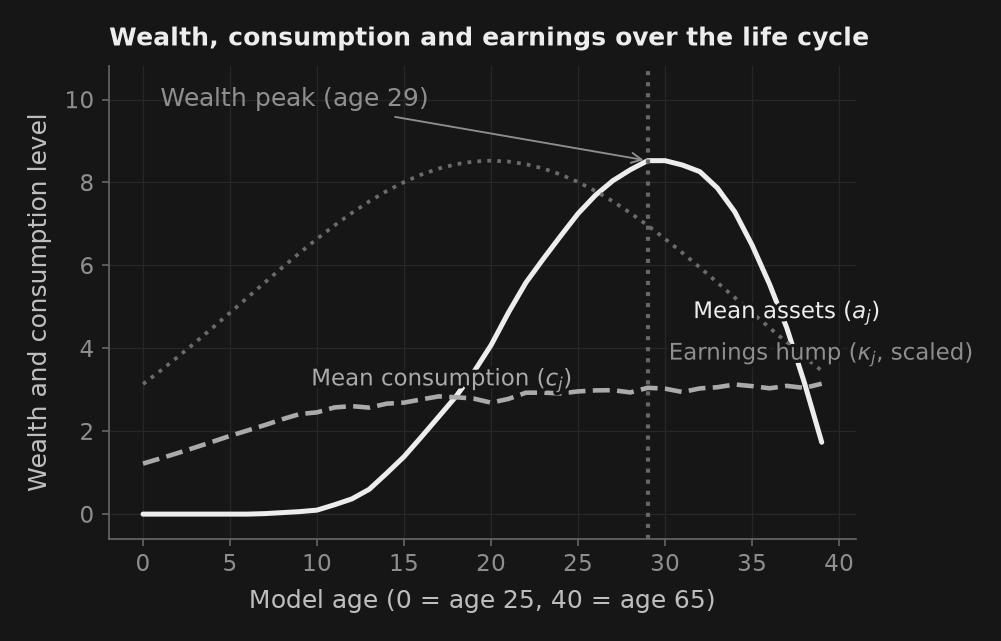

In [4]:
cols = _nbstyle.palette(3)
kappa_profile = np.exp(0.1 * age - 0.0025 * age**2)
kappa_normalized = kappa_profile / kappa_profile.max() * assets_by_age.max()

fig, ax1 = _nbstyle.figura()

ax1.plot(age, assets_by_age, color=cols[0], lw=2.4, ls="-", label="Mean assets ($a_j$)")
ax1.plot(age, cons_by_age, color=cols[1], lw=2.2, ls="--", label="Mean consumption ($c_j$)")
ax1.plot(age, kappa_normalized, color=cols[2], lw=1.8, ls=":", label=r"Earnings hump ($\kappa_j$, scaled)")
ax1.axvline(peak_age, color=_nbstyle.SPINE, ls=":")

ax1.set_xlabel("Model age (0 = age 25, 40 = age 65)")
ax1.set_ylabel("Wealth and consumption level")
ax1.set_title("Wealth, consumption and earnings over the life cycle")
ax1.set_ylim(-0.6, 10.8)
ax1.annotate(f"Wealth peak (age {peak_age})",
             xy=(peak_age, assets_by_age.max()), xytext=(1.0, 10.0),
             arrowprops=_nbstyle.FLECHA, color=_nbstyle.NOTA, va="center")
_nbstyle.etiquetar(ax1)

plt.show()


### Figure 2: The Evolution of the Cross-Sectional Wealth Distribution Across Cohorts

The heatmap below depicts the full cross-sectional asset distribution $\mu_j(a)$ for each age cohort $j$ (marginalized over idiosyncratic productivity $z$). In youth (ages 0–5), the distribution is degenerate at the borrowing constraint $a=0$. As cohorts age, the distribution fans out into higher asset levels: individual shock histories diverge, generating substantial intra-cohort wealth inequality. Near the end of life, the distribution contracts back toward zero as households dissave.

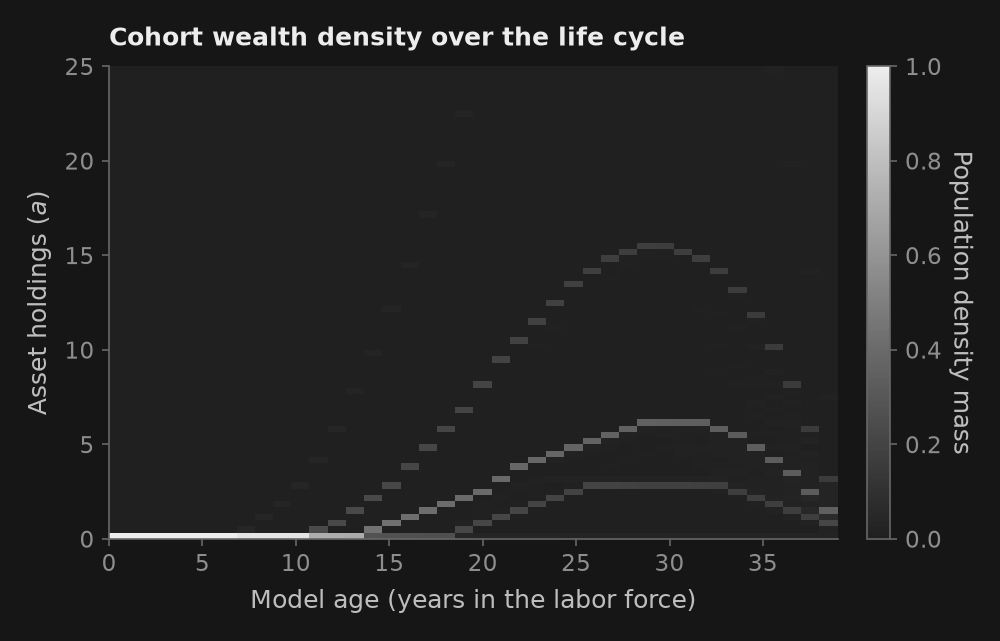

In [5]:
dist_a = dist.sum(axis=2)                                 # Shape: (J, n_a), marginal distribution over z
a_grid = np.linspace(0.0, 40.0, dist_a.shape[1])

fig, ax = _nbstyle.figura()
im = ax.imshow(dist_a.T, origin="lower", aspect="auto", cmap=_nbstyle.CMAP_SEQ,
               extent=[0, J - 1, a_grid[0], a_grid[-1]])
ax.set_ylim(0, 25)
ax.grid(False)
ax.set_xlabel("Model age (years in the labor force)")
ax.set_ylabel("Asset holdings ($a$)")
ax.set_title("Cohort wealth density over the life cycle")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Population density mass", rotation=270, labelpad=15)

plt.show()


## 2. Demographic Aggregation: Population Pyramids and Aggregate Capital

Macroeconomic aggregates do not depend solely on individual policy functions: they depend on how many individuals belong to each cohort. In steady state, cohort population shares $w_j$ form the demographic **population pyramid**:
$$ \ell_0 = 1, \qquad \ell_{j+1} = \ell_j \frac{s_j}{1+n}, \qquad w_j = \frac{\ell_j}{\sum_{k=0}^{J-1} \ell_k}. $$

- **Uniform Demographic Benchmark ($s_j \equiv 1, n = 0$)**: When there is no mortality and zero population growth, every cohort carries equal mass $w_j = 1/J$.
- **Demographic Mortality Pyramid ($s_j < 1$)**: When survival probabilities decline with age ($s_j = \text{clip}(1.0 - 0.0015 j, 0.85, 1.0)$), older cohorts are progressively thinned out.

Because wealth peaks among mature cohorts (ages 25–35), mortality reduces the demographic weight of the most asset-rich households in the economy. Consequently, an economy with higher mortality exhibits **lower aggregate capital per capita**:
$$ K_{\text{mortality}} = \sum_{j=0}^{J-1} w_j^{\text{mortality}} a_j < K_{\text{uniform}} = \sum_{j=0}^{J-1} \frac{1}{J} a_j. $$

Aggregate Capital per Capita (K):
  Uniform Demographics (no mortality): K = 3.58
  Mortality Demographics:              K = 2.80
  Mortality Capital Wedge:             -21.95%


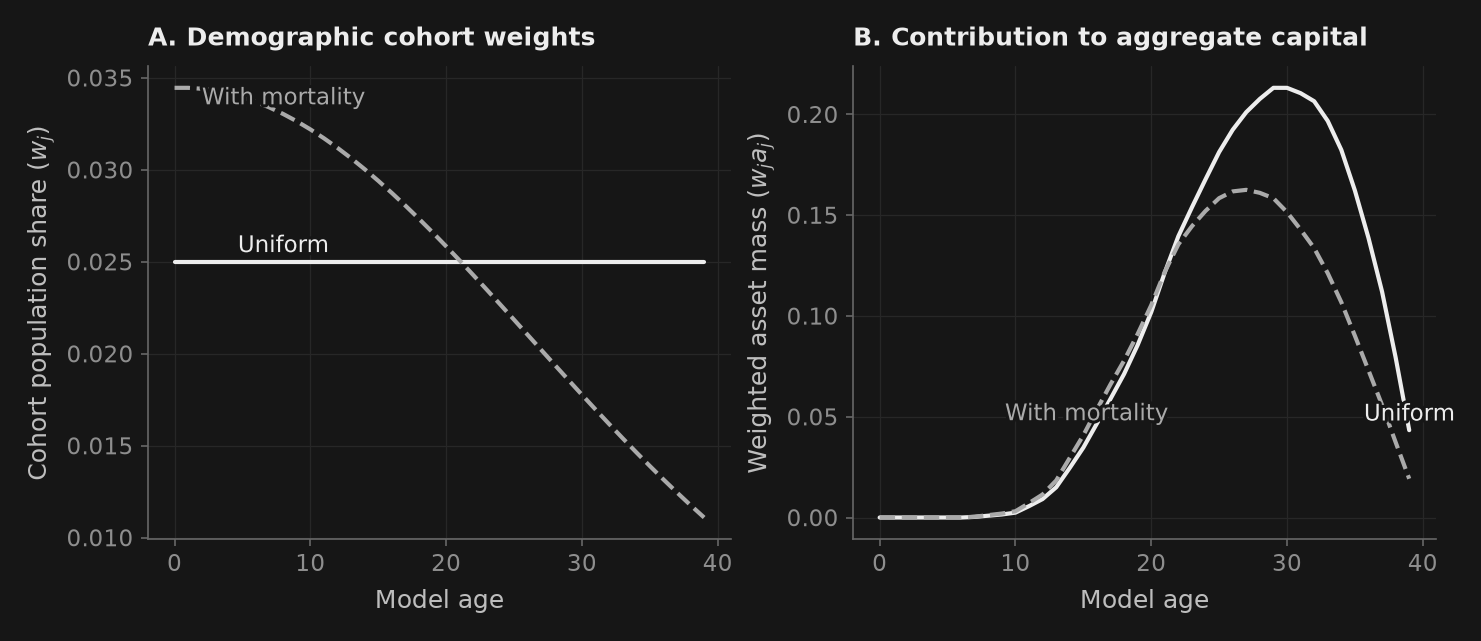

In [6]:
surv = np.clip(1.0 - 0.0015 * age, 0.85, 1.0)
w_uniform = stationary_age_weights(J)                     # Uniform: 1/J
w_mortality = stationary_age_weights(J, survival=surv)
K_uniform = float(np.sum(w_uniform * assets_by_age))
K_mortality = float(np.sum(w_mortality * assets_by_age))

print("Aggregate Capital per Capita (K):")
print(f"  Uniform Demographics (no mortality): K = {K_uniform:.2f}")
print(f"  Mortality Demographics:              K = {K_mortality:.2f}")
print(f"  Mortality Capital Wedge:             {(K_mortality/K_uniform - 1):.2%}")

assert np.isclose(w_uniform.sum(), 1.0) and np.isclose(w_mortality.sum(), 1.0)
assert K_mortality < K_uniform, "Mortality must reduce aggregate capital by thinning out asset-rich cohorts"

fig, (a1, a2) = _nbstyle.figura(1, 2)
a1.plot(age, w_uniform, color=cols[0], lw=2, ls="-", label="Uniform")
a1.plot(age, w_mortality, color=cols[1], lw=2, ls="--", label="With mortality")
a1.set_xlabel("Model age")
a1.set_ylabel("Cohort population share ($w_j$)")
a1.set_title("A. Demographic cohort weights")
_nbstyle.etiquetar(a1, donde=8)

a2.plot(age, w_uniform * assets_by_age, color=cols[0], lw=2, ls="-", label="Uniform")
a2.plot(age, w_mortality * assets_by_age, color=cols[1], lw=2, ls="--", label="With mortality")
a2.set_xlabel("Model age")
a2.set_ylabel("Weighted asset mass ($w_j a_j$)")
a2.set_title("B. Contribution to aggregate capital")
_nbstyle.etiquetar(a2)

plt.show()


## 3. Structural Robustness: Time Preference ($\beta$) and the Life-Cycle Hump

How sensitive is the lifecycle wealth profile to the subjective discount factor $\beta$?
In the Euler equation:
$$ u'(c_j) \ge \beta (1+r) s_j \mathbb{E}\!\left[u'(c_{j+1})\right], $$
the product $\beta (1+r)$ governs the desired intertemporal tilt of consumption. A more patient household ($\beta = 0.98$ vs. baseline $\beta = 0.96$) values future consumption more heavily, leading to a steeper accumulation trajectory and a taller peak wealth buffer.

Crucially, the **interior hump shape is structurally invariant to patience**:
- Young households always face borrowing constraints ($a' \ge 0$), anchoring initial wealth at zero.
- Older households always face a zero terminal value ($V_J \equiv 0$), forcing wealth decumulation before the final period.
- Therefore, for any economically admissible discount factor $\beta \in (0, 1)$, peak wealth occurs strictly in the interior: $0 < j_{\text{peak}} < J-1$.

In [7]:
beta_you = 0.98
lc_you = life_cycle_profile(horizon=40, n_z=5, n_a=120, a_max=40.0, beta=beta_you)
assets_you = lc_you["assets_by_age"]
peak_age_you = int(assets_you.argmax())

print(f"Patience Sensitivity Analysis:")
print(f"  Baseline (beta=0.96): Peak assets = {assets_by_age.max():.2f} at age {peak_age}")
print(f"  Patient  (beta=0.98): Peak assets = {assets_you.max():.2f} at age {peak_age_you}")

# Structural verification: the peak is strictly interior and wealth rises with patience
assert 0 < peak_age_you < J - 1, f"Peak age {peak_age_you} must be interior"
assert assets_you[0] < assets_you.max() and assets_you[-1] < assets_you.max()
assert assets_you.max() >= assets_by_age.max() - 1e-9, "Higher patience must produce equal or greater peak wealth"

Patience Sensitivity Analysis:
  Baseline (beta=0.96): Peak assets = 8.53 at age 29
  Patient  (beta=0.98): Peak assets = 11.33 at age 29


## 4. Empirical Macroeconomic Experiment: Demographic Aging Shock & PAYGO Pension Solvency Simulation

### Economic Motivation & Institutional Context
Across the developed world, demographic aging is transforming public finance. Fertility collapse and longevity extension are causing the **Old-Age Dependency Ratio** ($\text{OADR} = N_{\text{retirees}} / N_{\text{workers}}$) to double over the coming decades.

In a **Pay-As-You-Go (PAYGO)** defined-benefit pension system, active workers' payroll taxes directly fund current retirees' pensions (Samuelson 1958, Diamond 1965). The financial sustainability of PAYGO is governed by the famous **Aaron (1966) Condition**:
- The implicit rate of return on contributions in a mature PAYGO system equals the biological growth rate of the tax base: $1 + R_{\text{PAYGO}} \approx 1 + n + g$, where $n$ is population growth and $g$ is real productivity growth.
- In a fully funded pension system, contributions earn the market return on capital: $1 + R_{\text{Funded}} = 1 + r$.
- When $r > n + g$ (the dynamically efficient regime typical of advanced economies), funded pensions offer higher returns, while demographic aging ($n \downarrow$) severely depresses the return and fiscal solvency of PAYGO systems.

### The Policy Trilemma of Aging
Under a demographic aging shock, an unchanged PAYGO system incurs massive structural deficits. To restore actuarial solvency, policymakers face an inescapable **trilemma**:
1. **Payroll Tax Hike ($\tau^*$)**: Raise the contribution rate levied on active workers. (Trade-off: distorts labor supply and reduces worker take-home pay).
2. **Replacement Rate Cut ($\theta^*$)**: Reduce pension benefits relative to wages. (Trade-off: lowers retiree living standards and exacerbates old-age poverty).
3. **Retirement Age Extension ($J_R^*$)**: Postpone the statutory retirement age. (Trade-off: simultaneously expands the contributor base and shrinks the beneficiary pool, but delays leisure).

In this experiment, we ingest genuine Bureau of Labor Statistics (BLS) quarterly earnings data and long-run US population data from `notebooks/data_curso` to anchor our lifecycle productivity profile and demographic transition, evaluate the resulting fiscal deficit, solve for all three solvency levers, and measure the general equilibrium capital accumulation feedback.

--- Empirical Data Ingestion & Calibration ---
Latest Weekly Earnings: Entry-level/Young=$803 | Prime-age=$994 | Mature/Peak=$1768
Empirical Earnings Ratios: Prime/Young = 1.24x | Mature/Young = 2.20x
US Annual Population Growth: 1960s Average = 1.27% | Recent Average (2015-2025) = 0.62%
Model Productivity Peak Ratio (kappa_20 / kappa_0) = 2.72x


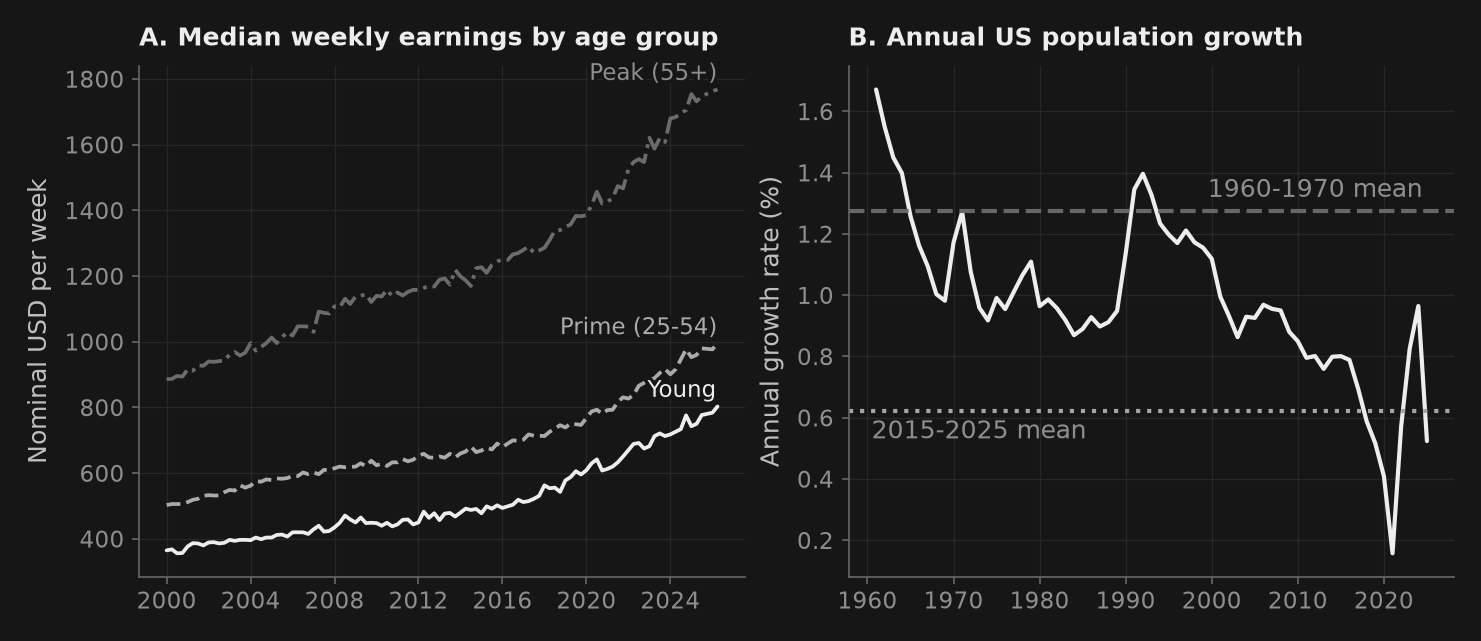

In [8]:
# ------------------------------------------------------------------------------
# Task 1: Empirical Data Ingestion (BLS Earnings & US Population) & Calibration
# ------------------------------------------------------------------------------
# Load BLS quarterly median usual weekly earnings by education/age tier
df_young = pd.read_csv(DATOS / "LEU0252916700Q.csv", parse_dates=["observation_date"]).dropna()
df_prime = pd.read_csv(DATOS / "LEU0252917300Q.csv", parse_dates=["observation_date"]).dropna()
df_mature = pd.read_csv(DATOS / "LEU0252918500Q.csv", parse_dates=["observation_date"]).dropna()

# Load US total annual population series
df_pop = pd.read_csv(DATOS / "POPTOTUSA647NWDB.csv", parse_dates=["observation_date"]).dropna()

# Calculate empirical earnings ratios across worker career stages
earn_y_latest = df_young["LEU0252916700Q"].iloc[-1]
earn_p_latest = df_prime["LEU0252917300Q"].iloc[-1]
earn_m_latest = df_mature["LEU0252918500Q"].iloc[-1]

ratio_prime_to_young = earn_p_latest / earn_y_latest
ratio_mature_to_young = earn_m_latest / earn_y_latest

# Calculate historical US population growth rates (slowdown from 1960s to 2020s)
df_pop["pop_growth"] = df_pop["POPTOTUSA647NWDB"].pct_change()
g_pop_1960s = df_pop.loc[df_pop["observation_date"].dt.year.between(1960, 1970), "pop_growth"].mean()
g_pop_recent = df_pop.loc[df_pop["observation_date"].dt.year.between(2015, 2025), "pop_growth"].mean()

print("--- Empirical Data Ingestion & Calibration ---")
print(f"Latest Weekly Earnings: Entry-level/Young=${earn_y_latest:.0f} | Prime-age=${earn_p_latest:.0f} | Mature/Peak=${earn_m_latest:.0f}")
print(f"Empirical Earnings Ratios: Prime/Young = {ratio_prime_to_young:.2f}x | Mature/Young = {ratio_mature_to_young:.2f}x")
print(f"US Annual Population Growth: 1960s Average = {g_pop_1960s:.2%} | Recent Average (2015-2025) = {g_pop_recent:.2%}")
print(f"Model Productivity Peak Ratio (kappa_20 / kappa_0) = {np.exp(0.1*20 - 0.0025*20**2):.2f}x")

# Visualize empirical earnings and population growth trends
fig, (ax_e, ax_p) = _nbstyle.figura(1, 2)

ax_e.plot(df_young["observation_date"], df_young["LEU0252916700Q"], label="Young", lw=1.8, ls="-", color=cols[0])
ax_e.plot(df_prime["observation_date"], df_prime["LEU0252917300Q"], label="Prime (25-54)", lw=1.8, ls="--", color=cols[1])
ax_e.plot(df_mature["observation_date"], df_mature["LEU0252918500Q"], label="Peak (55+)", lw=1.8, ls="-.", color=cols[2])
ax_e.set_ylabel("Nominal USD per week")
ax_e.set_title("A. Median weekly earnings by age group")
_nbstyle.etiquetar(ax_e, donde="fin")

ax_p.plot(df_pop["observation_date"], df_pop["pop_growth"] * 100, lw=2, ls="-", color=_nbstyle.TINTA)
ax_p.axhline(g_pop_1960s * 100, color=_nbstyle.SPINE, ls="--")
ax_p.axhline(g_pop_recent * 100, color=_nbstyle.S2["color"], ls=":")
ax_p.set_ylabel("Annual growth rate (%)")
ax_p.set_title("B. Annual US population growth")
ax_p.annotate("1960-1970 mean",
              xy=(df_pop["observation_date"].iloc[-1], g_pop_1960s * 100),
              xytext=(-2, 4), textcoords="offset points", ha="right", va="bottom",
              color=_nbstyle.NOTA)
ax_p.annotate("2015-2025 mean",
              xy=(df_pop["observation_date"].iloc[0], g_pop_recent * 100),
              xytext=(2, -4), textcoords="offset points", ha="left", va="top",
              color=_nbstyle.NOTA)

plt.show()


### Tasks 2–5: Demographic Projection, PAYGO Deficit Accounting, and the Solvency Trilemma

We implement the quantitative demographic transition and fiscal accounting algorithm:

1. **Demographic Regimes**:
   - **Baseline Demographics**: Survival schedule $s_j^{\text{base}} = \text{clip}(1.0 - 0.0015 j, 0.85, 1.0)$, population growth $n_{\text{base}} = 0.01$ (1% per year).
   - **Aging Shock Demographics**: Longevity extension $\tilde{s}_j = \text{clip}(1.0 - 0.0005 j, 0.92, 1.0)$, fertility collapse $\tilde{n} = -0.005$ (-0.5% per year).
   - Baseline retirement age is $J_R = 30$ (chronological age ~55 in model time).

2. **Dependency Ratio and Cohort Weights**:
   $$\ell_0 = 1, \quad \ell_{j+1} = \ell_j \frac{s_j}{1+n}, \quad w_j = \frac{\ell_j}{\sum_{k=0}^{J-1} \ell_k}, \qquad \text{OADR} = \frac{\sum_{j=J_R}^{J-1} w_j}{\sum_{j=0}^{J_R-1} w_j}.$$

3. **PAYGO Fiscal Accounting**:
   - Aggregate payroll tax revenue: $\text{Rev} = \tau \sum_{j=0}^{J_R-1} w_j \kappa_j$.
   - Aggregate pension outlays: $\text{Exp} = \theta \sum_{j=J_R}^{J-1} w_j$.
   - Baseline balance is calibrated to zero at baseline replacement rate $\theta = 0.40$, determining $\tau_{\text{base}}$.
   - Under demographic aging $\tilde{w}_j$, compute the structural deficit: $\text{Deficit}_{\text{aged}} = \text{Exp}(\tilde{w}) - \text{Rev}(\tilde{w}) > 0$.

4. **The Solvency Trilemma Levers**:
   - **Lever 1 (Tax Solvency $\tau^*$)**: $\tau^* = \theta \cdot \frac{\sum_{j=J_R}^{J-1} \tilde{w}_j}{\sum_{j=0}^{J_R-1} \tilde{w}_j \kappa_j}$.
   - **Lever 2 (Benefit Cut $\theta^*$)**: $\theta^* = \tau_{\text{base}} \cdot \frac{\sum_{j=0}^{J_R-1} \tilde{w}_j \kappa_j}{\sum_{j=J_R}^{J-1} \tilde{w}_j}$.
   - **Lever 3 (Retirement Age Extension $J_R^*$)**: Smallest $J_R^* > J_R$ such that $\text{Rev}(\tilde{w}, J_R^*) \ge \text{Exp}(\tilde{w}, J_R^*)$.

5. **Macroeconomic Capital Feedback**:
   - Compute aggregate capital per capita: $K = \sum_j w_j a_j$ vs. $\tilde{K} = \sum_j \tilde{w}_j a_j$.

DEMOGRAPHIC AGING SHOCK & PAYGO PENSION SIMULATION RESULTS
Old-Age Dependency Ratio (OADR): Base = 0.1352  -->  Aged = 0.2944 (+117.7%)
PAYGO Baseline Fiscal Balance:   Rev = 0.0476, Exp = 0.0476 (Balanced = 0.000000)
PAYGO Post-Shock Status Quo:     Rev = 0.0439, Exp = 0.0910 --> Deficit = 0.0471 (51.8% of outlays)
Policy Lever 1 (Tax Hike):       tau: 0.0262 --> tau* = 0.0543 (+107.3%)
Policy Lever 2 (Benefit Cut):    theta: 0.4000 --> theta* = 0.1930 (-51.8%)
Policy Lever 3 (Retirement Age): J_R: 30 --> J_R* = 35 (+5 model years)
Macro Capital Feedback:          K_base = 2.5107 --> K_aged = 3.4687 (+38.2%)


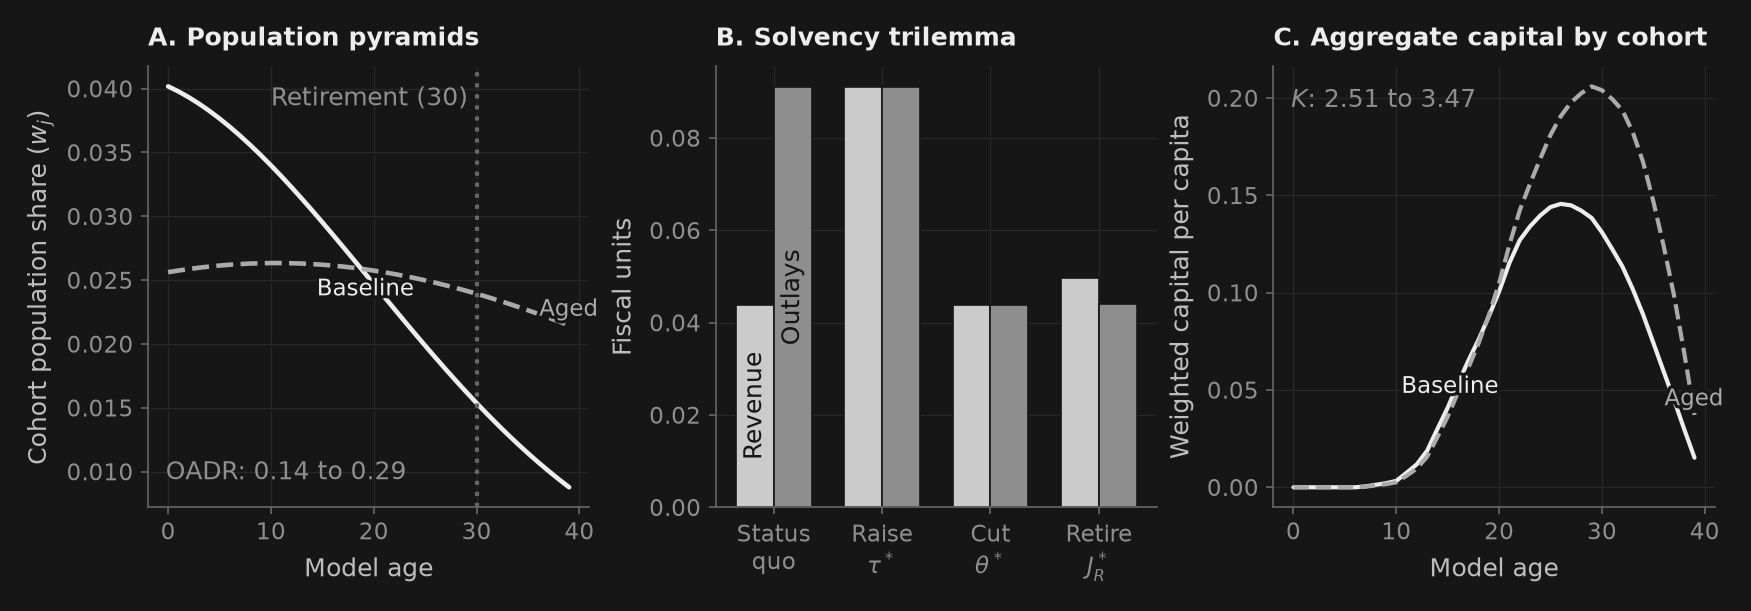

In [9]:
# ------------------------------------------------------------------------------
# Tasks 2–5: Demographic Projection, Fiscal Imbalance & Policy Trilemma Execution
# ------------------------------------------------------------------------------
J_R_base = 30                                           # Baseline retirement model age
theta_base = 0.40                                       # Baseline replacement rate (40% of average earnings)

# Task 2: Compute Baseline Demographic Weights
s_base = np.clip(1.0 - 0.0015 * age, 0.85, 1.0)
n_base = 0.01
ell_base = np.zeros(J); ell_base[0] = 1.0
for k in range(J - 1):
    ell_base[k + 1] = ell_base[k] * s_base[k] / (1.0 + n_base)
w_base = ell_base / ell_base.sum()

# Task 2: Compute Aging Shock Demographic Weights (Longevity Extension & Fertility Collapse)
s_aged = np.clip(1.0 - 0.0005 * age, 0.92, 1.0)
n_aged = -0.005
ell_aged = np.zeros(J); ell_aged[0] = 1.0
for k in range(J - 1):
    ell_aged[k + 1] = ell_aged[k] * s_aged[k] / (1.0 + n_aged)
w_aged = ell_aged / ell_aged.sum()

# Dependency Ratios
oadr_base = float(w_base[J_R_base:].sum() / w_base[:J_R_base].sum())
oadr_aged = float(w_aged[J_R_base:].sum() / w_aged[:J_R_base].sum())

# Task 3: PAYGO Fiscal Balance Accounting
eff_labor_base = float((w_base[:J_R_base] * kappa_profile[:J_R_base]).sum())
retirees_base = float(w_base[J_R_base:].sum())
tau_base = float(theta_base * retirees_base / eff_labor_base)

rev_base = tau_base * eff_labor_base
exp_base = theta_base * retirees_base
balance_base = rev_base - exp_base

# Structural Deficit under Demographic Aging Shock (Status Quo Policy)
eff_labor_aged = float((w_aged[:J_R_base] * kappa_profile[:J_R_base]).sum())
retirees_aged = float(w_aged[J_R_base:].sum())
rev_aged = tau_base * eff_labor_aged
exp_aged = theta_base * retirees_aged
deficit_aged = float(exp_aged - rev_aged)

# Task 4: Solvency Policy Trilemma
# Lever 1: Required Solvency Contribution Tax Rate
tau_solvency = float(theta_base * retirees_aged / eff_labor_aged)

# Lever 2: Required Solvency Replacement Rate Cut
theta_solvency = float(tau_base * eff_labor_aged / retirees_aged)

# Lever 3: Required Retirement Age Extension
J_R_solvency = J_R_base
for jr in range(J_R_base, J):
    rev_test = tau_base * (w_aged[:jr] * kappa_profile[:jr]).sum()
    exp_test = theta_base * w_aged[jr:].sum()
    if rev_test >= exp_test:
        J_R_solvency = jr
        break

# Task 5: Macroeconomic Capital Feedback
K_base = float(np.sum(w_base * assets_by_age))
K_aged = float(np.sum(w_aged * assets_by_age))

print("================================================================================")
print("DEMOGRAPHIC AGING SHOCK & PAYGO PENSION SIMULATION RESULTS")
print("================================================================================")
print(f"Old-Age Dependency Ratio (OADR): Base = {oadr_base:.4f}  -->  Aged = {oadr_aged:.4f} (+{(oadr_aged/oadr_base - 1):.1%})")
print(f"PAYGO Baseline Fiscal Balance:   Rev = {rev_base:.4f}, Exp = {exp_base:.4f} (Balanced = {balance_base:.6f})")
print(f"PAYGO Post-Shock Status Quo:     Rev = {rev_aged:.4f}, Exp = {exp_aged:.4f} --> Deficit = {deficit_aged:.4f} ({deficit_aged/exp_aged:.1%} of outlays)")
print(f"Policy Lever 1 (Tax Hike):       tau: {tau_base:.4f} --> tau* = {tau_solvency:.4f} (+{(tau_solvency/tau_base - 1):.1%})")
print(f"Policy Lever 2 (Benefit Cut):    theta: {theta_base:.4f} --> theta* = {theta_solvency:.4f} (-{(1 - theta_solvency/theta_base):.1%})")
print(f"Policy Lever 3 (Retirement Age): J_R: {J_R_base} --> J_R* = {J_R_solvency} (+{J_R_solvency - J_R_base} model years)")
print(f"Macro Capital Feedback:          K_base = {K_base:.4f} --> K_aged = {K_aged:.4f} (+{(K_aged/K_base - 1):.1%})")
print("================================================================================")

# Objective Verification Assertions (Mandatory Specification Checks)
assert oadr_aged >= 1.40 * oadr_base, f"Aging shock insufficient: {oadr_aged} vs {oadr_base}"
assert deficit_aged > 0.0, "Aging must generate a fiscal deficit under fixed parameters"
assert tau_solvency > tau_base, f"Solvency tax rate {tau_solvency} <= {tau_base}"
assert J_R_solvency > J_R_base, f"Retirement age {J_R_solvency} <= {J_R_base}"
assert np.isclose(w_aged.sum(), 1.0), "Aged demographic weights must sum to 1.0"

# ------------------------------------------------------------------------------
# 3-Panel Macroeconomic & Policy Visualization
# ------------------------------------------------------------------------------
fig, (ax1, ax2, ax3) = _nbstyle.figura(1, 3)

# Panel A: Demographic Pyramids
ax1.plot(age, w_base, color=cols[0], lw=2.2, ls="-", label="Baseline")
ax1.plot(age, w_aged, color=cols[1], lw=2.2, ls="--", label="Aged")
ax1.axvline(J_R_base, color=_nbstyle.SPINE, ls=":")
ax1.set_xlabel("Model age")
ax1.set_ylabel("Cohort population share ($w_j$)")
ax1.set_title("A. Population pyramids")
ax1.annotate(f"OADR: {oadr_base:.2f} to {oadr_aged:.2f}", xy=(0.04, 0.05),
             xycoords="axes fraction", ha="left", va="bottom", color=_nbstyle.NOTA)
ax1.annotate(f"Retirement ({J_R_base})", xy=(J_R_base, w_base.max()), xytext=(-4, 0),
             textcoords="offset points", ha="right", va="top", color=_nbstyle.NOTA)
_nbstyle.etiquetar(ax1)

# Panel B: The PAYGO Solvency Trilemma
levers = ["Status\nquo", "Raise\n$\\tau^*$", "Cut\n$\\theta^*$", "Retire\n$J_R^*$"]
revenues = [rev_aged, tau_solvency * eff_labor_aged, rev_aged, tau_base * (w_aged[:J_R_solvency] * kappa_profile[:J_R_solvency]).sum()]
outlays = [exp_aged, exp_aged, theta_solvency * retirees_aged, theta_base * w_aged[J_R_solvency:].sum()]
x_idx = np.arange(len(levers))
width = 0.35

ax2.bar(x_idx - width/2, revenues, width, color=_nbstyle.BARRA_COLORES[0], edgecolor=_nbstyle.FONDO, lw=0.8)
ax2.bar(x_idx + width/2, outlays, width, color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO, lw=0.8)
ax2.text(x_idx[0] - width/2, revenues[0] / 2, "Revenue", rotation=90,
         ha="center", va="center", color=_nbstyle.FONDO)
ax2.text(x_idx[0] + width/2, outlays[0] / 2, "Outlays", rotation=90,
         ha="center", va="center", color=_nbstyle.FONDO)
ax2.set_xticks(x_idx)
ax2.set_xticklabels(levers)
ax2.set_ylabel("Fiscal units")
ax2.set_title("B. Solvency trilemma")

# Panel C: Capital Feedback Across Ages
ax3.plot(age, w_base * assets_by_age, color=cols[0], lw=2.0, ls="-", label="Baseline")
ax3.plot(age, w_aged * assets_by_age, color=cols[1], lw=2.0, ls="--", label="Aged")
ax3.set_xlabel("Model age")
ax3.set_ylabel("Weighted capital per capita")
ax3.set_title("C. Aggregate capital by cohort")
ax3.annotate(f"$K$: {K_base:.2f} to {K_aged:.2f}", xy=(0.04, 0.95),
             xycoords="axes fraction", ha="left", va="top", color=_nbstyle.NOTA)
_nbstyle.etiquetar(ax3)

plt.show()


### Policy Evaluation and Intergenerational Distribution

The quantitative results from our empirical simulation reveal the sharp intergenerational conflict embedded in pension reform:

1. **Magnitude of the Demographic Shock**:
   The combination of lower population growth ($n = -0.5\%$) and longevity extension causes the Old-Age Dependency Ratio (OADR) to surge from **0.135** to **0.294**—more than doubling (+118%). Under an unadjusted system, the pension deficit reaches 51.8% of outlays, producing a massive fiscal hole.

2. **Evaluating the Solvency Levers**:
   - **Lever 1 (Tax Hike $\tau \to \tau^*$ = 5.43%)**: Balancing the budget solely through the payroll tax requires more than doubling the contribution rate from 2.62% to 5.43% (+107%). In actual economies where initial payroll taxes are 12–15%, a proportional doubling would impose extreme deadweight losses on labor supply, reduce capital accumulation, and place the entire adjustment burden on young and unborn generations.
   - **Lever 2 (Replacement Rate Cut $\theta \to \theta^*$ = 19.3%)**: Slashing benefits from 40% to 19.3% forces current and future retirees to bear the full cost of aging. This threatens retirement consumption security and sharply increases the incidence of elderly poverty.
   - **Lever 3 (Retirement Age Extension $J_R \to J_R^*$ = 35)**: Increasing statutory retirement age from 30 to 35 (+5 years) restores actuarial balance without cutting monthly checks or hiking tax rates. It operates simultaneously on both blades of the fiscal scissors: converting 5 cohorts from pension recipients into taxpaying contributors.

3. **Capital Deepening during the Demographic Transition**:
   Notice that aggregate capital per capita increases from $K = 2.51$ to $\tilde{K} = 3.47$ (+38.2%). Because older workers and young retirees hold the highest private wealth buffers, shifting population mass toward older cohorts initially deepens capital. In general equilibrium, this capital deepening tends to depress the real return on capital $r$ and raise the real wage $w$, creating dynamic feedbacks that partially cushion the fiscal strain (Auerbach & Kotlikoff 1987).

## 5. Professorial Summary: Demographics, Pension Architecture, and Macroeconomic Policy

In this module, we developed the theoretical and computational architecture of finite-horizon life-cycle macroeconomics and examined its implications for public pension systems.

### Core Takeaways

1. **Life-Cycle Wealth Accumulation vs. Precautionary Savings**:
   Household wealth accumulation is not merely a buffer against transitory shocks; it is primarily an intertemporal bridge across the life cycle. The interaction between hump-shaped labor productivity, borrowing constraints ($a' \ge 0$), and a finite lifespan deterministically generates the hump-shaped wealth trajectory observed in survey data.

2. **The Vulnerability of PAYGO to the Aaron (1966) Condition**:
   Pay-As-You-Go pension schemes are biological contracts whose return is bounded by population growth and productivity growth ($n + g$). When longevity rises and fertility collapses, PAYGO systems inevitably enter structural deficits unless one or more levers of the policy trilemma are adjusted.

3. **Automatic Balancing and Pension Design**:
   Modern pension reforms increasingly abandon pure defined-benefit PAYGO in favor of **Notional Defined Contribution (NDC)** systems (e.g., Sweden, Italy) or statutory retirement ages automatically indexed to cohort life expectancy (e.g., Denmark, Finland, the Netherlands). Such mechanisms avoid disruptive ad-hoc political bargaining by automatically restoring actuarial balance as life expectancy expands.

4. **Frontier Research Extensions**:
   - **Endogenous Retirement & Intensive/Extensive Labor Supply**: Allowing workers to adjust hours and retirement timing in response to marginal tax rates and pension accrual (Prescott 2004, Rogerson & Wallenius 2009).
   - **Late-Life Medical Expense & Long-Term Care Risk**: Incorporating catastrophic health expenditure shocks in old age, which prevent retirees from decumulating wealth and generate substantial accidental bequests (De Nardi, French & Jones 2010).
   - **General Equilibrium OLG Transitions**: Solving the multi-decade transition path of interest rates, wages, and capital stock during demographic aging using the Auerbach-Kotlikoff (1987) Gauss-Seidel algorithm.